# Fuzzy Support Vector Machine (FSVM) Implementation

## Cel laboratorium
Implementacja Fuzzy SVM w oparciu o artykuł "Fuzzy Support Vector Machines" oraz porównanie wyników z klasycznym SVM.

### Teoria Fuzzy SVM
Fuzzy SVM rozszerza klasyczny SVM poprzez przypisanie każdemu punktowi treningowemu wartości przynależności (membership value) **s_i ∈ (0, 1]**. Ta wartość określa "ważność" punktu w procesie uczenia:
- Punkty z wysoką przynależnością (bliskie 1) mają większy wpływ na hyperplane
- Punkty z niską przynależnością (bliskie 0) - prawdopodobne outliers - mają mniejszy wpływ

### Modyfikacja funkcji celu
Klasyczny SVM:
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \xi_i$$

Fuzzy SVM:
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n s_i\xi_i$$

gdzie **s_i** to fuzzy membership value.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import make_classification
from sklearn.datasets import make_moons
import time
from sklearn.svm import SVC

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Implementacja Fuzzy SVM

### Metody obliczania Fuzzy Membership

Zaimplementujemy kilka metod obliczania wartości przynależności:

1. **Distance-based membership**: Bazuje na odległości punktu od centroidu klasy
   - Punkty bliższe centroidowi mają wyższą przynależność
   
2. **Radius-based membership**: Wykorzystuje promień dla każdej klasy
   - Punkty w promieniu r od centroidu mają pełną przynależność
   
3. **KNN-based membership**: Bazuje na lokalnej gęstości punktów
   - Wykorzystuje odległość do k-tego najbliższego sąsiada

In [42]:
class SVM:
    def __init__(self, kernel='linear', learning_rate=0.5, C=1.0, poly_degree=3, gamma=0.5):
        self.lr = learning_rate
        self.kernel = kernel
        self.degree = poly_degree
        self.gamma = gamma
        self.C = C
        self.lambdas = None
        self.X = None
        self.y = None
        self.b = None
        self.support_vectors = None

    def kernel_function(self, X1, X2):
        if self.kernel == 'linear':
            return X1 @ X2.T
        elif self.kernel == 'poly':
            return ((X1 @ X2.T) + 1) ** self.degree
        elif self.kernel == 'rbf':
            X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
            X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
            dist = X1_sq - 2 * X1 @ X2.T + X2_sq
            return np.exp(-self.gamma * dist)
    
    def dual_svm(self, lambdas, X, y):
        K = self.kernel_function(X, X)
        L = np.outer(lambdas, lambdas)
        Y = np.outer(y, y)
        return -np.sum(lambdas) + 0.5 * np.sum(L * Y * K)
        
    def fit(self, X, y):
        n_samples = X.shape[0]
        self.X = X
        self.y = y

        # Ograniczenia
        bounds = [(0, self.C) for _ in range(n_samples)]
        constraints = {'type': 'eq', 'fun': lambda l: np.dot(l, y)}

        init_lambdas = np.random.rand(n_samples)

        result = minimize(
            fun=self.dual_svm,
            x0=init_lambdas,
            args=(X, y),
            bounds=bounds,
            constraints=constraints,
            method='SLSQP',
            options={'disp': False, 'maxiter': 1000}
        )
        self.lambdas = result.x

        tol = 1e-5
        self.support_vectors = self.lambdas > tol

        # Wybieramy punkty z przedziału (0, C) czyli punkty nośne na granicy marginesu
        margin_sv = (self.lambdas > tol) & (self.lambdas < self.C - tol)
        margin_points = margin_sv if np.any(margin_sv) else self.support_vectors

        sv_y = y[margin_points] 
        K = self.kernel_function(X[margin_points], X[self.support_vectors])
        lambdas_y = self.lambdas[self.support_vectors] * self.y[self.support_vectors]
        self.b = np.mean(sv_y - np.dot(K, lambdas_y))

    def prepare_predict(self, X):
        K = self.kernel_function(X, self.X[self.support_vectors])
        l_y = self.lambdas[self.support_vectors] * self.y[self.support_vectors]
        return np.dot(K, l_y) + self.b

    def predict(self, X):
        return np.sign(self.prepare_predict(X))
    
    @property
    def n_support_(self):
        """Zwraca liczbę support vectors dla zgodności z API."""
        if self.support_vectors is None:
            return 0
        return [np.sum(self.support_vectors)]
    
    @property
    def support_vectors_(self):
        """Zwraca support vectors dla zgodności z API."""
        if self.support_vectors is None or self.X is None:
            return None
        return self.X[self.support_vectors]

In [43]:
class FuzzySVM:
    def __init__(self, kernel='rbf', C=1.0, gamma=0.5, poly_degree=3,
                 membership_type='distance', k_neighbors=5):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.poly_degree = poly_degree
        self.membership_type = membership_type
        self.k_neighbors = k_neighbors
        self.svm = None
        self.memberships = None
        
    def compute_distance_membership(self, X, y):
        """
        Membership na podstawie odległości od centroidu klasy.
        """
        memberships = np.ones(len(X))
        classes = np.unique(y)
        
        for c in classes:
            class_mask = (y == c)
            X_class = X[class_mask]
            
            centroid = np.mean(X_class, axis=0)
            
            distances = np.linalg.norm(X_class - centroid, axis=1)
            
            max_dist = np.max(distances) if np.max(distances) > 0 else 1.0
            memberships[class_mask] = 1.0 - (distances / max_dist) * 0.9 + 0.1
            
        return memberships
    
    
    def compute_sequential_membership(self, X, y, decay_factor=0.9):
        """
        membership na podstawie kolejności danych (sekwencyjnej).
        """
        n_samples = len(X)
        memberships = np.zeros(n_samples)

        for i in range(n_samples):
            position_from_end = n_samples - 1 - i
            memberships[i] = decay_factor ** position_from_end
        
        memberships = memberships * 0.9 + 0.1
        
        return memberships
    
    def compute_class_weight_membership(self, X, y, positive_weight=1.0, negative_weight=0.1):
        """
        membership na podstawie różnej ważności klas.
        """
        memberships = np.where(y == 1, positive_weight, negative_weight)
        return memberships

    
    def fit(self, X, y):
        y_converted = np.where(y == 0, -1, y)
        
        # Oblicz fuzzy membership values
        if self.membership_type == 'distance':
            self.memberships = self.compute_distance_membership(X, y_converted)
        elif self.membership_type == 'sequential':
            self.memberships = self.compute_sequential_membership(X, y_converted)
        elif self.membership_type == 'class_weight':
            self.memberships = self.compute_class_weight_membership(X, y_converted)
        else:
            raise ValueError(f"Unknown membership type: {self.membership_type}")
        
        self.svm = FuzzySVMCore(
            kernel=self.kernel,
            C=self.C,
            gamma=self.gamma,
            poly_degree=self.poly_degree,
            memberships=self.memberships 
        )
        
        self.svm.fit(X, y_converted)
        
        return self
    
    def predict(self, X):
        predictions = self.svm.predict(X)
        return np.where(predictions <= 0, -1, 1)
    
    def score(self, X, y):
        predictions = self.predict(X)
        return accuracy_score(y, predictions)
    
    def get_memberships(self):
        return self.memberships


class FuzzySVMCore(SVM):
    def __init__(self, kernel='rbf', C=1.0, gamma=0.5, poly_degree=3, memberships=None):
        super().__init__(kernel=kernel, C=C, gamma=gamma, poly_degree=poly_degree)
        self.memberships = memberships
        
    def fit(self, X, y):
        n_samples = X.shape[0]
        self.X = X
        self.y = y

        if self.memberships is not None:
            bounds = [(0, self.C * s_i) for s_i in self.memberships]
        else:
            bounds = [(0, self.C) for _ in range(n_samples)]
            
        constraints = {'type': 'eq', 'fun': lambda l: np.dot(l, y)}

        init_lambdas = np.random.rand(n_samples)

        result = minimize(
            fun=self.dual_svm,
            x0=init_lambdas,
            args=(X, y),
            bounds=bounds,
            constraints=constraints,
            method='SLSQP',
            options={'disp': False, 'maxiter': 1000}
        )
        self.lambdas = result.x

        tol = 1e-5
        self.support_vectors = self.lambdas > tol

        if self.memberships is not None:
            # Dla Fuzzy SVM: punkty na marginesie mają 0 < lambda_i < C * s_i
            margin_sv = (self.lambdas > tol) & (self.lambdas < np.array([self.C * s_i for s_i in self.memberships]) - tol)
        else:
            margin_sv = (self.lambdas > tol) & (self.lambdas < self.C - tol)
            
        margin_points = margin_sv if np.any(margin_sv) else self.support_vectors

        sv_y = y[margin_points] 
        K = self.kernel_function(X[margin_points], X[self.support_vectors])
        lambdas_y = self.lambdas[self.support_vectors] * self.y[self.support_vectors]
        self.b = np.mean(sv_y - np.dot(K, lambdas_y))

### Testy obu SVM:

In [44]:
def generate_data(n_samples, n_features, random_state):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features,
        n_redundant=0,
        n_clusters_per_class=1,
        random_state=random_state
    )
    y = 2 * y - 1
    return X, y

def generate_moons(n_samples, random_state):
    X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.1, random_state=random_state)
    y_moons = 2 * y_moons - 1
    return X_moons, y_moons

def generate_noisy_data(n_samples=200, n_features=2, noise_scale=3.0, random_state=None):
    rng = np.random.default_rng(random_state)
    
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features,
        n_redundant=0,
        n_clusters_per_class=1,
        flip_y=0.3,  
        class_sep=0.5,
        random_state=random_state
    )
    
    noise = rng.normal(loc=0.0, scale=noise_scale, size=X.shape)
    X_noisy = X + noise
    
    y = 2 * y - 1
    
    return X_noisy, y

In [45]:
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc

def evaluate_classifier(y_test, y_pred, X, y, model, classifier_name, dataset_name, labels=[0,1], decision_plot=True):
    # Oblicz metryki
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    # Wyświetl metryki
    print(f"{classifier_name} na {dataset_name}:")
    print(f"Skuteczność: {accuracy*100:.4f}%")
    print(f"Czułość (Recall): {sensitivity*100:.4f}%")
    print(f"Swoistość: {specificity*100:.4f}%")
    print(f"ROC AUC: {roc_auc:.4f}")

    fig = plt.figure(figsize=(20, 6))
    plt.suptitle(f"WYNIKI DLA: {classifier_name} na zbiorze: {dataset_name}", fontsize=16, y=1.05)

    axes = fig.subplots(1, 3)

    # Macierz pomyłek
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
    axes[0].set_title("Macierz pomyłek")

    # Krzywa ROC
    axes[1].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--') 
    axes[1].set_xlabel('1 - Swoistość (False Positive Rate)')
    axes[1].set_ylabel('Czułość (True Positive Rate)')
    axes[1].set_title('Krzywa ROC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    if decision_plot:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                            np.arange(y_min, y_max, 0.01))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        custom_cmap = ListedColormap(['red', 'blue'])
        axes[2].contourf(xx, yy, Z, alpha=0.4, cmap=custom_cmap)
        scatter = axes[2].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=custom_cmap, s=50)
        axes[2].set_title("Granica decyzyjna")
        axes[2].set_xlabel("Feature 1")
        axes[2].set_ylabel("Feature 2")
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()


### Klasyczny SVM:

Własna implementacja Poly na Noisy data:
Skuteczność: 50.0000%
Czułość (Recall): 31.5789%
Swoistość: 66.6667%
ROC AUC: 0.4912


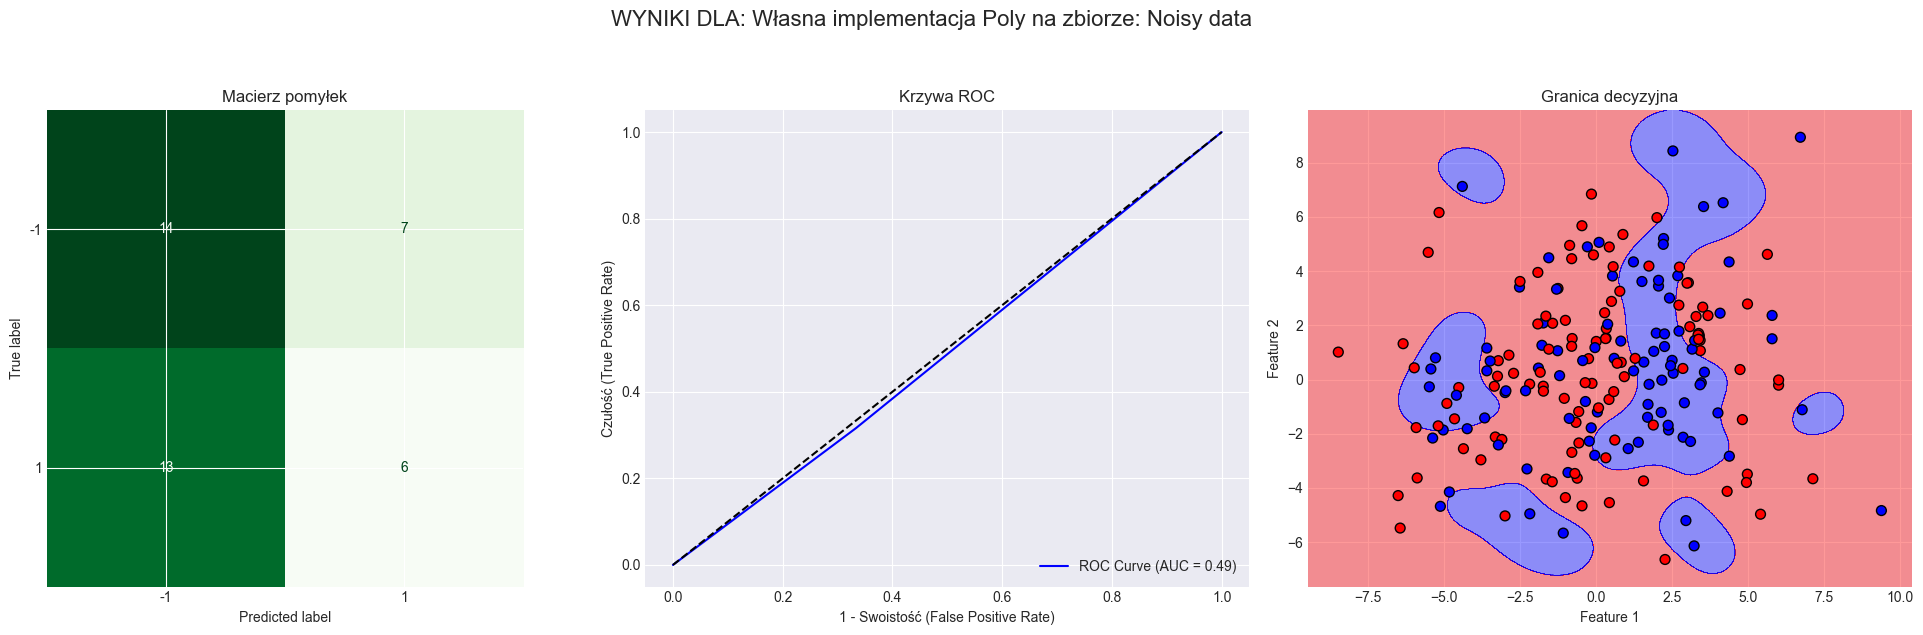

In [46]:
X_generate, y_generate = generate_data(200, 2, 259195)
X_gen_train, X_gen_test, y_gen_train, y_gen_test = train_test_split(X_generate, y_generate, test_size=0.2, random_state=259195)

X, y = generate_noisy_data(200, 2, noise_scale=3.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm = SVM(kernel='rbf')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
evaluate_classifier(y_test, svm_pred, X, y, svm, "Własna implementacja Poly", "Noisy data", [-1, 1])


### Fuzzy SVM z funkcją przynależności *distance*:

[ 1 -1  1  1  1  1  1 -1 -1  1 -1  1  1 -1 -1  1 -1 -1 -1  1  1  1 -1 -1
  1 -1 -1  1 -1  1  1 -1  1 -1 -1 -1 -1 -1  1 -1]
[ 1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1 -1 -1  1  1 -1 -1 -1  1
 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1]
Fuzzy SVM Poly (distance) na Noisy Data:
Skuteczność: 55.0000%
Czułość (Recall): 26.3158%
Swoistość: 80.9524%
ROC AUC: 0.5363


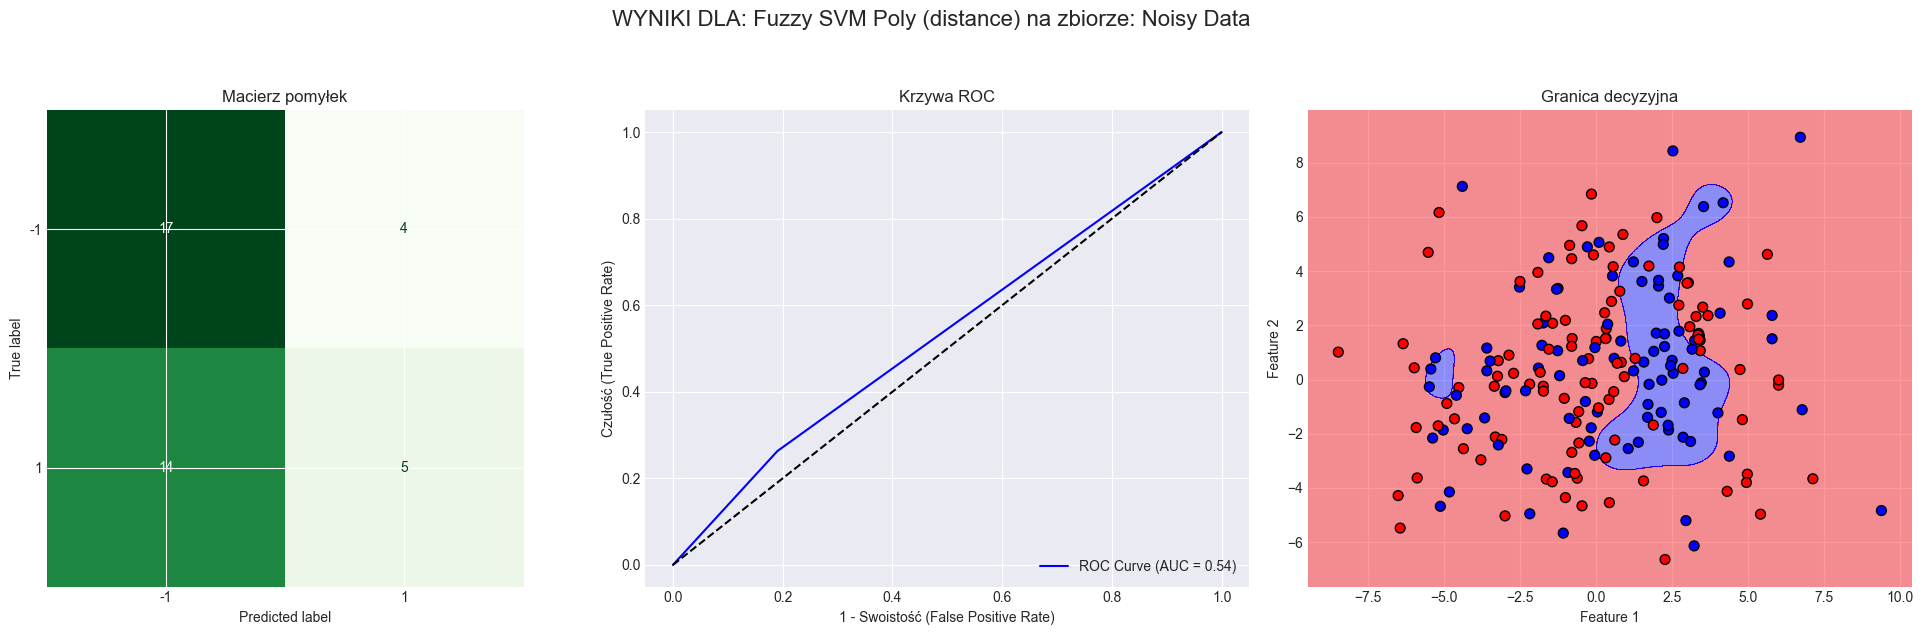

In [47]:
fuzzy_svm = FuzzySVM(kernel='rbf', membership_type='distance', C=1.0)
fuzzy_svm.fit(X_train, y_train)
fuzzy_svm_pred = fuzzy_svm.predict(X_test)
print(y_test)
print(fuzzy_svm_pred)
evaluate_classifier(y_test, fuzzy_svm_pred, X, y, fuzzy_svm, "Fuzzy SVM Poly (distance)", "Noisy Data", [-1, 1])